<a href="https://colab.research.google.com/github/sakshimohite8/ML_Practicals_MCA/blob/main/03_Iris_Data_Representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
df = pd.DataFrame(iris)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [ ]:
df.median(numeric_only=True)

,0
sepal_length,5.80
sepal_width,3.00
petal_length,4.35
petal_width,1.30


In [ ]:
df.min(numeric_only=True)

,0
sepal_length,4.3
sepal_width,2.0
petal_length,1.0
petal_width,0.1


In [ ]:
df.std(numeric_only=True)

,0
sepal_length,0.828066
sepal_width,0.435866
petal_length,1.765298
petal_width,0.762238


In [ ]:
df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["species_encoded"] = le.fit_transform(df["species"])
print(df.head())
print(df.tail())

   sepal_length  sepal_width  petal_length  petal_width species  \
0           5.1          3.5           1.4          0.2  setosa   
1           4.9          3.0           1.4          0.2  setosa   
2           4.7          3.2           1.3          0.2  setosa   
3           4.6          3.1           1.5          0.2  setosa   
4           5.0          3.6           1.4          0.2  setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  
     sepal_length  sepal_width  petal_length  petal_width    species  \
145           6.7          3.0           5.2          2.3  virginica   
146           6.3          2.5           5.0          1.9  virginica   
147           6.5          3.0           5.2          2.0  virginica   
148           6.2          3.4           5.4          2.3  virginica   
149           5.9          3.0           5.1          1.8  virginica   

     species_encoded  
145            

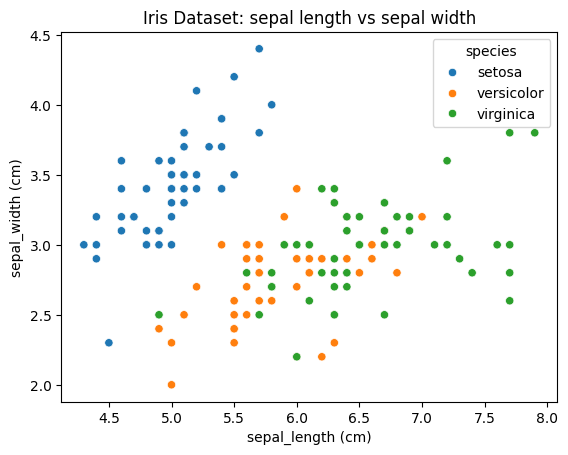

In [ ]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")
plt.title("Iris Dataset: sepal length vs sepal width")
plt.xlabel("sepal_length (cm)")
plt.ylabel("sepal_width (cm)")
plt.show()

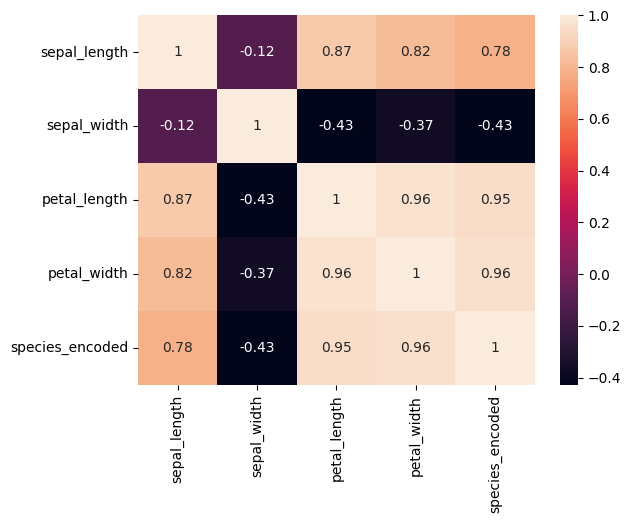

In [ ]:
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)
plt.show()

In [ ]:
x = df.drop(["species", "species_encoded"], axis=1)
y = df["species_encoded"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("x_train", x_train.shape)
print("x_test", x_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

x_train (120, 4)
x_test (30, 4)
y_train (120,)
y_test (30,)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)

model

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = model.predict(x_test)
print("Predicted values")
print(y_pred)

Predicted values
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [ ]:
new_data = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_data)
print("predicted species code", prediction[0])

predicted species code 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
